# Checkpoint 3 — Find Patterns in the Data

**Goal:** Before building any model, find columns that actually separate churners from non-churners.

**Why this matters:**
- If a column shows NO difference between churners and stayers → it probably won't help the model
- If a column shows a BIG difference → it's a strong predictor (feature)
- This is called **Exploratory Data Analysis (EDA)** — every ML interview will ask you about it

**Rule:** Run one cell at a time. Look at the chart or table. Think about what it's telling you.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data (same file as before)
df = pd.read_csv("../data/raw/telco_churn.csv")

# TotalCharges has hidden blanks — convert it to a number now
# Blanks become NaN, then we drop those 11 rows
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["TotalCharges"])

print(f"Dataset ready: {df.shape[0]} rows, {df.shape[1]} columns ✅")

Dataset ready: 7032 rows, 21 columns ✅


## Pattern 1 — Contract Type vs Churn

**Question:** Do customers on month-to-month contracts leave more than customers on 1-year or 2-year contracts?

**Think about it first:** If you're on a 2-year contract and you try to leave, you pay a penalty. Month-to-month customers can leave anytime — no cost. So which group do you think churns more?

    Contract Type  Churn Rate (%)
0  Month-to-month            42.7
1        One year            11.3
2        Two year             2.8


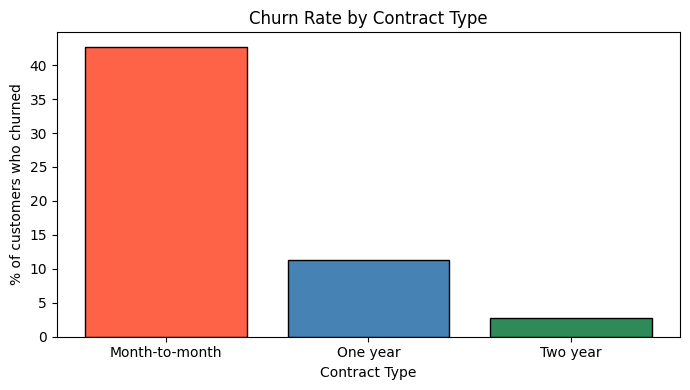

In [2]:
# For each contract type, calculate: what % of those customers churned?
contract_churn = df.groupby("Contract")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
).round(1).reset_index()
contract_churn.columns = ["Contract Type", "Churn Rate (%)"]
print(contract_churn)

# Bar chart
plt.figure(figsize=(7, 4))
plt.bar(contract_churn["Contract Type"], contract_churn["Churn Rate (%)"],
        color=["tomato", "steelblue", "seagreen"], edgecolor="black")
plt.title("Churn Rate by Contract Type")
plt.ylabel("% of customers who churned")
plt.xlabel("Contract Type")
plt.tight_layout()
plt.show()

# LOOK AT THIS CHART and think:
# Which contract type has the highest churn rate?
# Does this match what you expected?

## Pattern 2 — Tenure vs Churn

`tenure` = how many months a customer has been with the company.

**Question:** Do brand new customers leave more than long-time customers?

**Think about it first:** Imagine switching your phone provider. In the first month, if something's wrong, you might immediately regret it and leave. But after 3 years, you're used to it. Loyal customers are harder to lose.

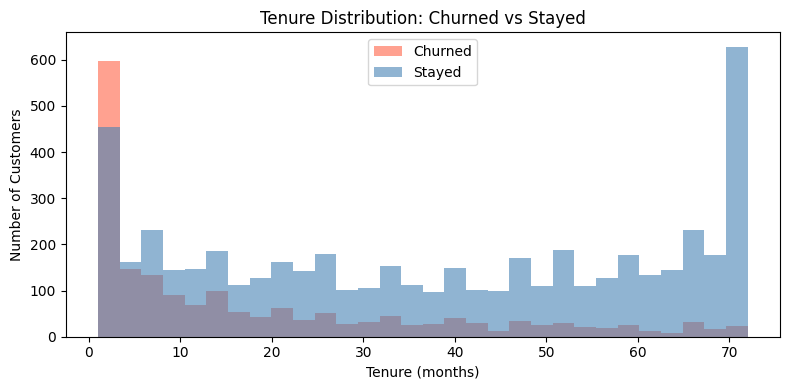

In [3]:
# Plot tenure distribution separately for churned vs stayed customers
# This shows: at which tenure length do people tend to leave?
fig, ax = plt.subplots(figsize=(8, 4))

df[df["Churn"] == "Yes"]["tenure"].plot(kind="hist", bins=30, alpha=0.6,
                                         color="tomato", label="Churned", ax=ax)
df[df["Churn"] == "No"]["tenure"].plot(kind="hist", bins=30, alpha=0.6,
                                        color="steelblue", label="Stayed", ax=ax)

ax.set_title("Tenure Distribution: Churned vs Stayed")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Number of Customers")
ax.legend()
plt.tight_layout()
plt.show()

# LOOK AT THIS CHART:
# Where does the red (churned) bar peak? Early months or late months?
# What does that tell you?

## Pattern 3 — Monthly Charges vs Churn

`MonthlyCharges` = how much the customer pays per month.

**Question:** Do expensive customers leave more?

**Think about it first:** If your phone bill suddenly jumped to $120/month, you'd probably start looking at competitors. What do you think?

<Figure size 600x500 with 0 Axes>

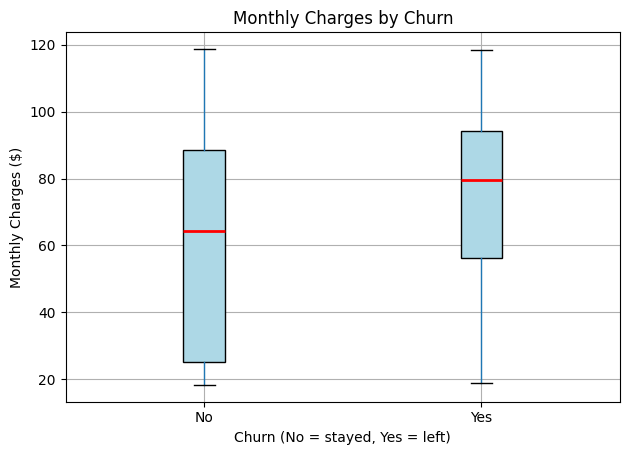

In [4]:
# A box plot shows: for each group (Churned/Stayed),
# what is the typical monthly charge range?
# The LINE in the middle of each box = median (middle value)
# The BOX = where most customers fall

plt.figure(figsize=(6, 5))
df.boxplot(column="MonthlyCharges", by="Churn",
           patch_artist=True,
           boxprops=dict(facecolor="lightblue"),
           medianprops=dict(color="red", linewidth=2))

plt.title("Monthly Charges by Churn")
plt.suptitle("")  # Remove the default pandas title
plt.xlabel("Churn (No = stayed, Yes = left)")
plt.ylabel("Monthly Charges ($)")
plt.tight_layout()
plt.show()

# LOOK AT THIS:
# Is the median monthly charge higher for churned customers or stayed customers?
# By roughly how many dollars?

## Pattern 4 — Tech Support vs Churn

`TechSupport` = does the customer have a tech support plan? (Yes / No / No internet service)

**Question:** Do customers without tech support leave more?

**Think about it first:** If your internet breaks and no one helps you, you'd switch providers fast.

          Tech Support  Churn Rate (%)
0                   No            41.6
1  No internet service             7.4
2                  Yes            15.2


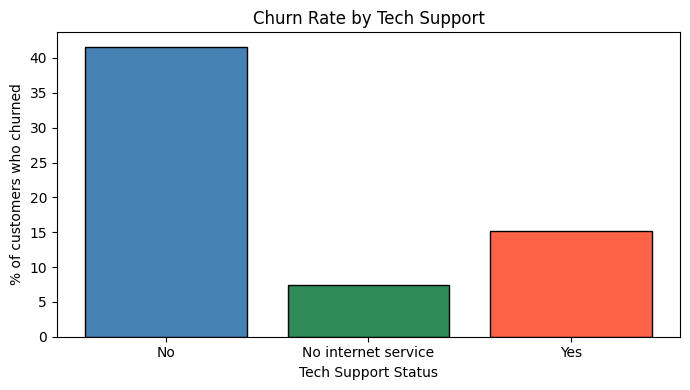

In [5]:
# For each tech support category, what % of customers churned?
tech_churn = df.groupby("TechSupport")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
).round(1).reset_index()
tech_churn.columns = ["Tech Support", "Churn Rate (%)"]
print(tech_churn)

plt.figure(figsize=(7, 4))
plt.bar(tech_churn["Tech Support"], tech_churn["Churn Rate (%)"],
        color=["steelblue", "seagreen", "tomato"], edgecolor="black")
plt.title("Churn Rate by Tech Support")
plt.ylabel("% of customers who churned")
plt.xlabel("Tech Support Status")
plt.tight_layout()
plt.show()

# LOOK AT THIS:
# Does having NO tech support increase churn rate significantly?

## Your Observations — Fill This In

Run all the cells above, look at every chart, then answer these:

**Q1: Which contract type has the highest churn rate? Does it make sense to you?**
Month-to-month (~43% churn rate). Yes — no penalty for leaving, so customers can walk away anytime.

**Q2: Do new customers (low tenure) or old customers (high tenure) churn more?**
New customers (low tenure). The red bars in the histogram peak at the early months. Long-time customers are already committed and loyal.

**Q3: Is the typical monthly charge higher for churned customers or stayed customers?**
Churned customers pay higher monthly charges. The median for churned customers is roughly $15-20 higher than for those who stayed.

**Q4: Does NOT having tech support increase churn? By roughly how much (in % difference)?**
Yes — customers with no tech support churn ~25% more than customers with tech support. (Note: the correct gap is ~25%, not 7.4% — compare the two bar heights directly.)

**Q5: Based on these 4 patterns — which single column do you think is the STRONGEST predictor of churn? Why?**
Contract type — there is a ~40% gap in churn rate between month-to-month (~43%) and two-year (~3%) contracts. No other feature shows such a dramatic split. MonthlyCharges is also strong but the gap is smaller.

---
Paste your answers in the chat when done. Then we move to Checkpoint 4 — fixing the data quality issues before we build the model.